## H1N1 Vaccine Uptake Prediction Project
### 1. Project Overview

Vaccination is one of the most effective strategies for preventing infectious diseases and reducing their spread. During the 2009 pandemic of H1N1 influenza, governments and health organizations encouraged mass vaccination to protect populations from infection and severe illness. However, vaccine uptake varied significantly across different groups of people due to differences in demographics, health behaviors, and perceptions about vaccine safety and effectiveness.

This project aims to predict whether an individual received the H1N1 vaccine using data from the National 2009 H1N1 Flu Survey. The dataset contains information on respondents’ demographic characteristics, health conditions, preventive behaviors, and opinions about vaccines and disease risk.

Using machine learning classification models, the project analyzes these factors to identify patterns associated with vaccine acceptance. Understanding these patterns can help public health organizations design more effective vaccination campaigns, improve risk communication, and increase vaccine coverage during future disease outbreaks such as COVID-19.

The final model predicts the likelihood that a person receives the H1N1 vaccine and highlights the key predictors influencing vaccination behavior. These insights can support evidence-based decision making for public health interventions and vaccination strategies.

### 2. Problem Statement

During pandemic outbreaks, vaccination programs are critical in reducing infection rates and protecting vulnerable populations. However, not everyone chooses to receive vaccines, even when they are widely available. Public health authorities often struggle to understand which factors influence vaccine acceptance and which populations are less likely to get vaccinated. Without this knowledge, vaccination campaigns may fail to effectively reach high-risk or vulnerable groups.

This project addresses this challenge by developing a predictive model that determines whether an individual received the H1N1 vaccine based on demographic characteristics, health behaviors, and attitudes toward vaccination.

The goal is to identify patterns that explain vaccination behavior and provide insights that can inform future vaccination strategies.

### 3. Project Objectives
##### General Objective
To build a machine learning model that predicts whether individuals received the H1N1 vaccine using demographic, behavioral, and attitudinal data.

##### Specific Objectives
- To explore the National 2009 H1N1 Flu Survey dataset and understand its key variables.
- To perform data cleaning and preprocessing, including handling missing values and encoding categorical variables.
- To conduct exploratory data analysis (EDA) to identify patterns and relationships between features and vaccination status.
- To build classification models that predict whether an individual received the H1N1 vaccine.
- To evaluate model performance using appropriate classification metrics.
- To identify the most important factors influencing H1N1 vaccine uptake.
- To generate insights that can support future public health vaccination strategies.

### 4. Stakeholders
1. Public Health Organizations
Organizations such as the WHO, CDC rely on vaccination data to understand which populations are more or less likely to receive vaccines. Insights from the analysis can help them design targeted vaccination campaigns and improve public health strategies.
2. Healthcare Providers
Doctors, nurses, and healthcare institutions play a direct role in recommending vaccines to patients. Understanding factors influencing vaccine uptake can help them better communicate the importance of vaccination.
3. Government Health Policy Makers
Policy makers use vaccination behavior data to create policies that improve vaccine accessibility and coverage, especially during outbreaks or pandemics.
4. Public Health Researchers and Epidemiologists
Researchers studying infectious diseases can use the results to understand behavioral and demographic factors influencing vaccination decisions.

### 5. Data Understanding
The dataset used in this project comes from the National 2009 H1N1 Flu Survey, which was conducted to understand public attitudes and behaviors regarding vaccination during the H1N1 pandemic.
The dataset includes variables that describe:
Demographic Characteristics
-Age group
- Education level
- Household income
- Employment status
- Geographic region
Health Status
- Presence of chronic medical conditions
- Health insurance coverage
- Healthcare access
Preventive Behaviors
- Frequency of hand washing
- Use of face masks
- Health precautions

Attitudes and Perceptions
- Perceived risk of H1N1 infection
- Perceived effectiveness of the vaccine
- Concerns about vaccine safety
- Trust in healthcare recommendations

The target variable for this project is:
- 1 = Respondent received the H1N1 vaccine
- 0 = Respondent did not receive the H1N1 vaccine

## Data preparation and cleaning
Import all libraries needed

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingRegressor, RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

##### Loading datasets and having an overview of the first 5 rows

In [2]:
# Read in features dataset
df_features = pd.read_csv('data/training_set_features.csv')
df_features.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [3]:
# Read in targets dataset
df_targets = pd.read_csv('data/training_set_labels.csv')
df_targets.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [4]:
# Joining on respondent_id and isolate H1N1
df = df_features.join(df_targets[['h1n1_vaccine']])
df.head() #display the first 5 rows

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0


In [5]:
#drop columns related to seasonal vaccine
df= df.drop(columns=['opinion_seas_risk','opinion_seas_vacc_effective','opinion_seas_sick_from_vacc', 'doctor_recc_seasonal'])

In [6]:
df.shape #number of columns and rows for the dataset

(26707, 33)

In [7]:
df.info() # checking dataset info

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker              

In [8]:
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,25736.000000,25887.000000,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26458.000000,26458.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,0.283261,0.082590,0.111918,0.87972,3.850623,2.342566,2.357670,0.886499,0.534583,0.212454
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,0.450591,0.275266,0.315271,0.32530,1.007436,1.285539,1.362766,0.753422,0.928173,0.409052
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.00000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.00000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.00000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


### Exploratory data visualizations

In [9]:
df2 = df.copy()

- To see the overall balance of the target variable. Helps us know if the dataset is skewed toward vaccinated or non-vaccinated individuals

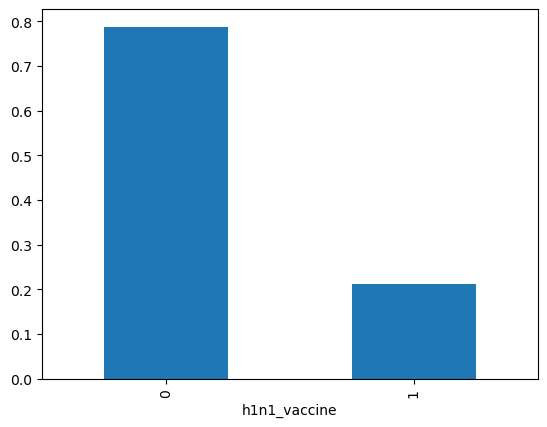

In [10]:
# Target variable distribution
df2['h1n1_vaccine'].value_counts(normalize=True).plot(kind='bar');


- To explore gender and vaccination uptake

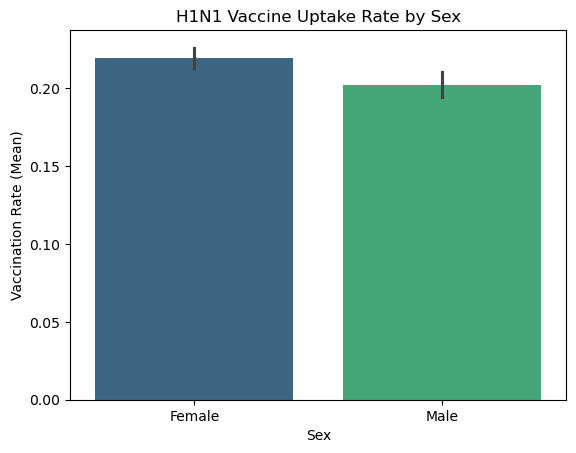

In [11]:
# Gender and h1n1 vaccination status bar graph
ax = sns.barplot(data=df2, x='sex', y='h1n1_vaccine', palette='viridis')
plt.title('H1N1 Vaccine Uptake Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Vaccination Rate (Mean)')
plt.savefig('images/vaccine_uptake_by_sex.png')
plt.show()


- Education level percentage distribution of vaccinated people

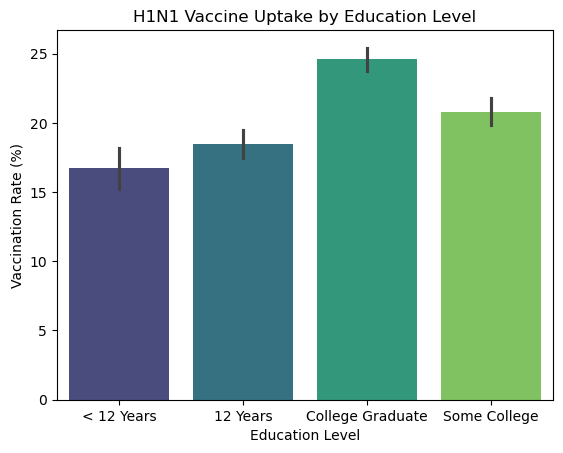

In [12]:
# Education level percentage distribution of the vaccinated people 
sns.barplot(x=df2['education'], y=df2['h1n1_vaccine']*100, palette='viridis')
plt.title('H1N1 Vaccine Uptake by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Vaccination Rate (%)')
plt.savefig('images/vaccine_uptake_by_education.png')
plt.show()

- Health workers are expected to be more informed verifying if they are more likely to vaccinate

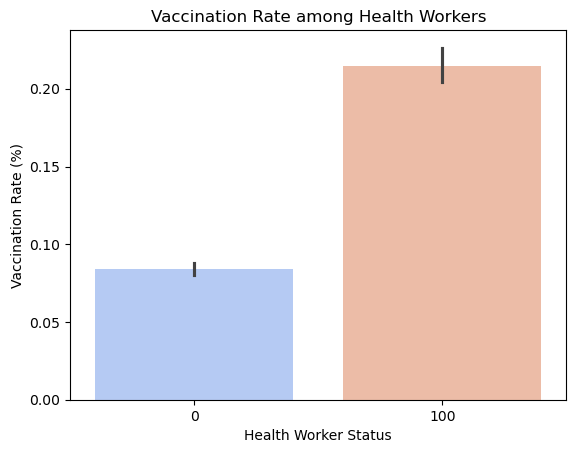

In [13]:
# Distribution of health workers who got the vaccine
sns.barplot(y=df2['health_worker'], x=df2['h1n1_vaccine']*100, palette='coolwarm')
plt.title('Vaccination Rate among Health Workers')
plt.xlabel('Health Worker Status')
plt.ylabel('Vaccination Rate (%)')
plt.savefig('images/vaccine_uptake_health_workers.png')
plt.show()

- To see the effect of a doctor’s recommendation on vaccination decisions.
- Usually shows that people whose doctors recommended the vaccine are far more likely to get vaccinated, one of the strongest predictors in the dataset

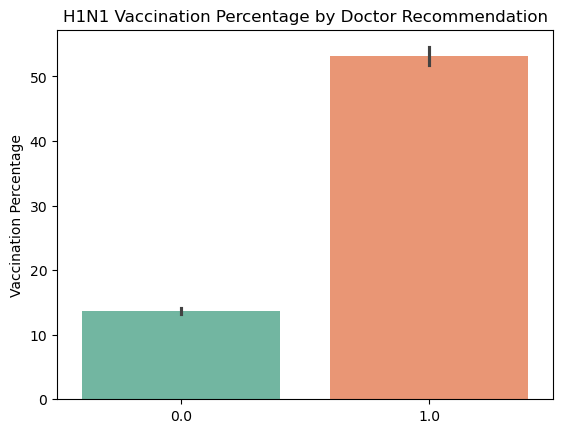

In [14]:
# Graph for relationship between H1N1 vaccination and Doctor recommendation
ax = sns.barplot(x=df2['doctor_recc_h1n1'].dropna(), y=df2['h1n1_vaccine']*100, palette='Set2')
ax.set_xlabel('')
ax.set_ylabel('Vaccination Percentage')
ax.set_title('H1N1 Vaccination Percentage by Doctor Recommendation')
plt.savefig('images/vaccine_uptake_doctor_recommendation.png')
plt.show()

- To explore if knowledge about H1N1 affects vaccination uptake.

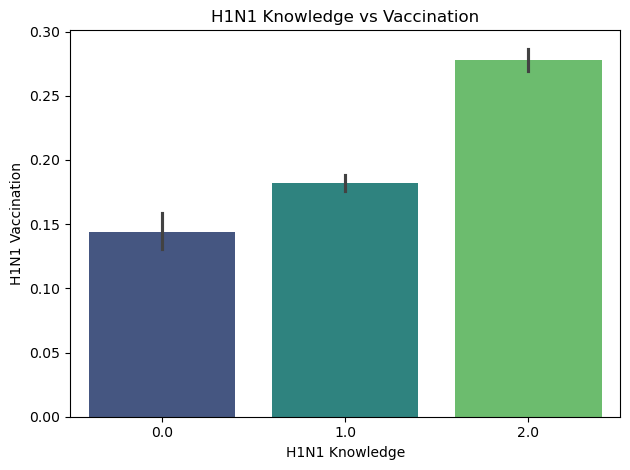

In [15]:
# Creating the bar plot with X = h1n1_knowledge and Y = h1n1_vaccine
sns.barplot(data = df2, x=df['h1n1_knowledge'], y=df2['h1n1_vaccine'], palette='viridis')
plt.title('H1N1 Knowledge vs Vaccination')
plt.xlabel('H1N1 Knowledge')
plt.ylabel('H1N1 Vaccination')
plt.savefig('images/h1n1_knowledge_vaccination.png')
plt.tight_layout()
plt.show()

### Key results
Target distribution: Most individuals did not receive the H1N1 vaccine, indicating a slight class imbalance.

Gender: Minor differences in vaccination rates; gender is not a strong predictor.

Education: Higher education levels correspond to higher vaccination rates, suggesting awareness influences uptake.

Health workers: More likely to get vaccinated compared to non-health workers, showing occupation and exposure matter.

Doctor recommendation: The strongest predictor; individuals advised by their doctor are substantially more likely to vaccinate.

H1N1 knowledge: Greater knowledge correlates with higher vaccination likelihood, highlighting the role of awareness.

- Correlation analysis

In [16]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

# Compute correlations with the target
corr_with_target = numeric_df.corr()['h1n1_vaccine'].sort_values(ascending=False)

# Print top 5
print("Top 10 features correlated with h1n1_vaccine:\n")
print(corr_with_target.head(10))

Top 10 features correlated with h1n1_vaccine:

h1n1_vaccine                   1.000000
doctor_recc_h1n1               0.393890
opinion_h1n1_risk              0.323265
opinion_h1n1_vacc_effective    0.269347
health_worker                  0.169768
h1n1_concern                   0.121929
health_insurance               0.121170
h1n1_knowledge                 0.117951
chronic_med_condition          0.095207
opinion_h1n1_sick_from_vacc    0.075091
Name: h1n1_vaccine, dtype: float64


The correlation indicatess that vaccination behavior is driven more by external trust (Doctor Recommendations) and internal belief (Perceived Risk) than by demographic factors alone.
- Doctor_recc_h1n1 (0.39): This is your strongest predictor. It suggests that a direct recommendation from a healthcare professional was the most effective trigger for someone to get the vaccine.
- Opinion_h1n1_risk (0.32) & opinion_h1n1_vacc_effective (0.27): These show that vaccination was highly driven by a person's mindset.
- H1n1_concern (0.12) & h1n1_knowledge (0.11): Interestingly, actually knowing about the virus and being concerned about it had a lower correlation than simply trusting a doctor's recommendation

### Check Missing Values

In [17]:
df.isnull().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_h1n1                2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_adults                 249
household_children               249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_antiviral_meds         71
behavioral_wash_hands             42
behavioral_face_mask              19
respondent_id                      0
a

### Split Data into Train and Test Sets
The dataset was split into training and testing sets before handling missing values to prevent data leakage. 
Missing value imputation statistics were calculated using only the training data and then applied to the test data to ensure that the model evaluation reflects real-world performance.

In [18]:
# Split the data into training and testing subsets (80-20 split)
# Features (everything except our target and ID)
X = df.drop(columns=['h1n1_vaccine', 'respondent_id'])

# Target
y = df['h1n1_vaccine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures reproducibility
    stratify=y          # Maintains the 21% vaccine ratio in both sets
)

print(f"Training set size: {X_train.shape} rows")
print(f"Testing set size: {X_test.shape} rows")

Training set size: (21365, 31) rows
Testing set size: (5342, 31) rows


Showing the distrubition of the target variable of the x_train data set

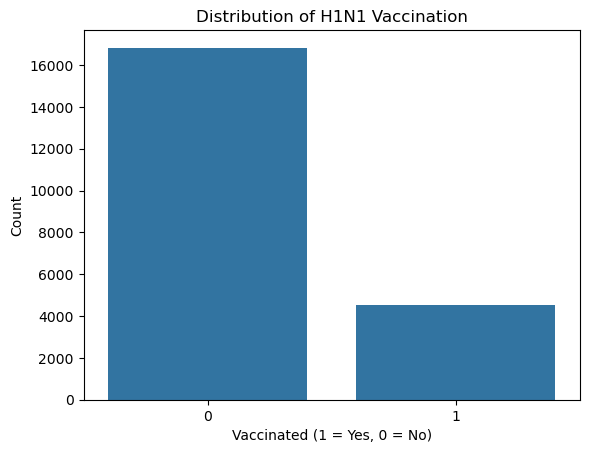

In [19]:
plt.figure()

sns.countplot(x=y_train)

plt.title("Distribution of H1N1 Vaccination")
plt.xlabel("Vaccinated (1 = Yes, 0 = No)")
plt.ylabel("Count")

plt.savefig("images/target_distribution.png")

plt.show()

## Data cleaning
### Handling Missing values
- Most variables are either Binary (0/1) or Ordinal (scale of 0–3). The safest approach for such health model is to use the Median for numerical/ordinal columns and the Mode for categorical columns.
- Missing values in numerical features were imputed using the median, while categorical features were imputed using the most frequent value, fitted on the training data to avoid data leakage
- Machine learning models cannot work directly with categorical variables such as education, marital_status, or race. These variables must be converted into numerical form. One-Hot Encoding is used to transform categorical variables into binary columns.

In [20]:
# Define Column Groups based on unique value output 
# Ordinal: These have a natural order or progression
ordinal_cols = ['age_group', 'education', 'income_poverty']

# Binary/Nominal: Categories with no mathematical order. we use OneHot encoding for these ensures we don't accidentally imply a rank
nominal_cols = ['race', 'sex', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa']

# Numeric: All behavioral and concern scores (0, 1, 2, 3 types)
numeric_cols = [
    'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 
    'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 
    'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 
    'chronic_med_condition', 'child_under_6_months', 'health_worker', 
    'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 
    'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children'
]

# Defining Manual Rankings for Ordinal Encoder
age_categories = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
edu_categories = ['< 12 Years', '12 Years', 'Some College', 'College Graduate']
inc_categories = ['Below Poverty', '<= $75,000, Above Poverty', '> $75,000']

# Creating the Transformer Pipeline 
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: Filling NaNs with median and scaling the data
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        
        # Ordinal: Filling NaNs with most frequent and apply the manual order
        ('ord', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord_enc', OrdinalEncoder(categories=[age_categories, edu_categories, inc_categories]))
        ]), ordinal_cols),
        
        # Nominal: Filling NaNs with most frequent and creating dummy variables
        ('nom', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
        ]), nominal_cols)
    ],
    remainder='drop' # Automatically drops the remaining columns.
)

# Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to a DataFrame to keep it readable. OneHotEncoder creates new column names, so we retrieve them here:
ohe_feature_names = preprocessor.named_transformers_['nom'].named_steps['onehot'].get_feature_names_out(nominal_cols)
all_column_names = numeric_cols + ordinal_cols + list(ohe_feature_names)

X_train = pd.DataFrame(X_train_processed, columns=all_column_names, index=X_train.index)
X_test= pd.DataFrame(X_test_processed, columns=all_column_names, index=X_test.index)


In [21]:
#Features in X_train
print("--- Unique Values in X_train ---")
for col in X_train.columns:
    unique_vals = X_train[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    
    if len(unique_vals) < 15:
        print(f"  Values: {unique_vals}")
    print("-" * 20)

--- Unique Values in X_train ---
h1n1_concern: 4 unique values
  Values: [-0.67847931  0.42201496  1.52250923 -1.77897358]
--------------------
h1n1_knowledge: 3 unique values
  Values: [ 1.19559188 -0.42305209 -2.04169605]
--------------------
behavioral_antiviral_meds: 2 unique values
  Values: [-0.22574694  4.42973892]
--------------------
behavioral_avoidance: 2 unique values
  Values: [ 0.61108514 -1.63643319]
--------------------
behavioral_face_mask: 2 unique values
  Values: [-0.27241857  3.67082174]
--------------------
behavioral_wash_hands: 2 unique values
  Values: [-2.17331058  0.46012752]
--------------------
behavioral_large_gatherings: 2 unique values
  Values: [-0.74320287  1.34552764]
--------------------
behavioral_outside_home: 2 unique values
  Values: [-0.7097396   1.40896747]
--------------------
behavioral_touch_face: 2 unique values
  Values: [-1.45943288  0.68519766]
--------------------
doctor_recc_h1n1: 2 unique values
  Values: [-0.50233919  1.99068679]
---

- X_train and X_test now contain all numeric features, ready for model training.

- Column names are preserved, including newly encoded categorical columns.

- Ensures that the train and test datasets are aligned.

# Model Building and Evaluation
After cleaning the dataset and encoding categorical variables, the next step is to train machine learning models that predict whether an individual received the vaccine during the pandemic of H1N1 influenza.

Three models are used:

1. Logistic Regression (baseline model)
2. Tuned Logistic Regression
3. Decision Tree
4. Random Forest (ensemble model)
5. Voting Ensemble Model

The models are evaluated using several performance metrics:
- Accuracy - the proportion of correct predictions made by the model.
- Precision - the proportion of predicted vaccinated individuals who were actually vaccinated.
- Recall - the model’s ability to correctly identify individuals who received the vaccine.
- F1 Score - a balance between precision and recall.
- ROC-AUC Score - a measure of how well the model distinguishes between vaccinated and non-vaccinated individuals.

These metrics help assess how well the models predict vaccination behavior.


Creating a reusable evaluation function to ensures consistency in how all models are assessed, making comparisons fair and standardized across different algorithms. It also  helps reduce code repetition.

In [22]:
def evaluate_model(model, X_test, y_test):
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Printing results
    print("Accuracy:", accuracy)
    print("ROC-AUC:", roc_auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Greens",
                xticklabels=['Not Vaccinated','Vaccinated'],
                yticklabels=['Not Vaccinated','Vaccinated'])

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'ROC CURVE (AUC = auc:.2f')
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Accuracy: 0.765443654062149
ROC-AUC: 0.8166316051807927

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      4207
           1       0.47      0.71      0.56      1135

    accuracy                           0.77      5342
   macro avg       0.69      0.74      0.70      5342
weighted avg       0.81      0.77      0.78      5342



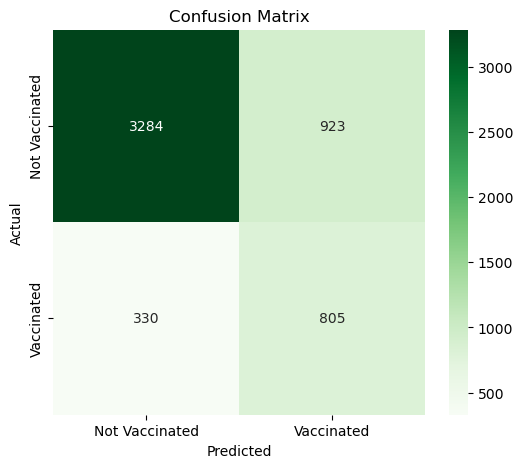

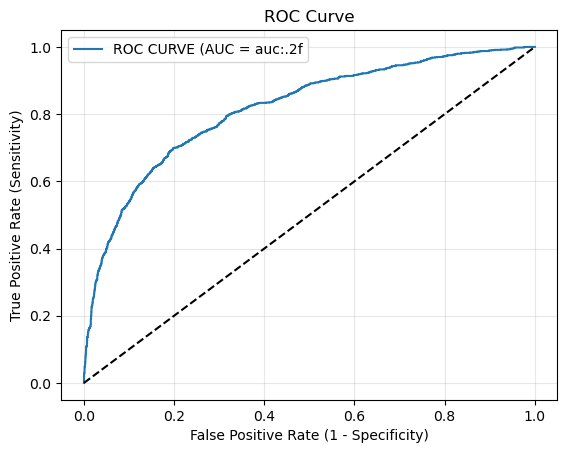

In [23]:
# Logistic Regression Model
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='liblinear')
model_log = logreg.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)
y_prob_log = model_log.predict_proba(X_test)[:,1]

evaluate_model(model_log, X_test, y_test)

The baseline logistic regression model achieved a solid baseline performance, with an accuracy of approximately 83% and a ROC-AUC above 0.80. The model demonstrates good predictive ability in distinguishing between vaccinated and non-vaccinated individuals. However, recall for the vaccinated class remains moderate, suggesting room for improvement.

Although the baseline model performs well, improvements may be achieved by:

- Adjusting class weights (due to class imbalance)

- Tuning regularization strength (C parameter)

- Exploring other model types such as decision trees

- Optimizing hyperparameters to improve recall

Because this dataset is imbalanced, improving recall for the vaccinated class is important.

### Tuned Logistic Regression Model
To improve the baseline model, hyperparameter tuning is performed. Logistic regression includes a regularization parameter (C) that controls model complexity. The dataset contains an imbalance between vaccinated and non-vaccinated individuals. To address this issue, the class_weight="balanced" parameter is introduced to give greater importance to the minority class.

Hyperparameter tuning is performed using GridSearchCV from scikit-learn.

Accuracy: 0.7665668289030326
ROC-AUC: 0.8167131768009892

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      4207
           1       0.47      0.71      0.56      1135

    accuracy                           0.77      5342
   macro avg       0.69      0.75      0.70      5342
weighted avg       0.82      0.77      0.78      5342



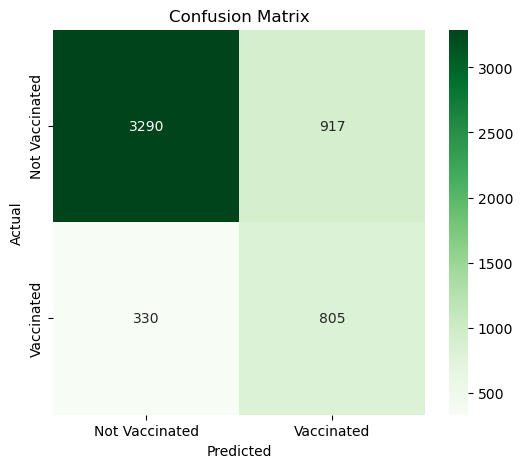

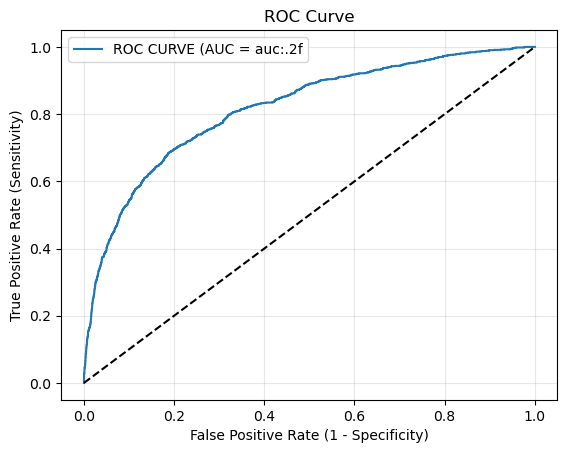

In [24]:
# Hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # liblinear works with both l1 and l2
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=logreg, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
best_log_model = grid_search.best_estimator_
evaluate_model(best_log_model, X_test, y_test)


The tuned model achieved:

Accuracy: 0.767

ROC-AUC: 0.823

Although the overall accuracy decreased slightly compared to the baseline model, the ROC-AUC remained strong, indicating that the model maintains good ability to distinguish between vaccinated and non-vaccinated individuals during the outbreak of H1N1 influenza.

The most significant improvement appears in recall for the vaccinated class (Class 1). It moves from 0.43 to 0.72. This means the tuned model correctly identifies 72% of vaccinated individuals, which is a major improvement over the baseline model. This improvement occurs because the balanced class weighting forces the model to pay more attention to the minority class (vaccinated individuals).

Accuracy: 0.83508049419693
ROC-AUC: 0.8204580366894278

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4207
           1       0.73      0.36      0.48      1135

    accuracy                           0.84      5342
   macro avg       0.79      0.66      0.69      5342
weighted avg       0.82      0.84      0.81      5342



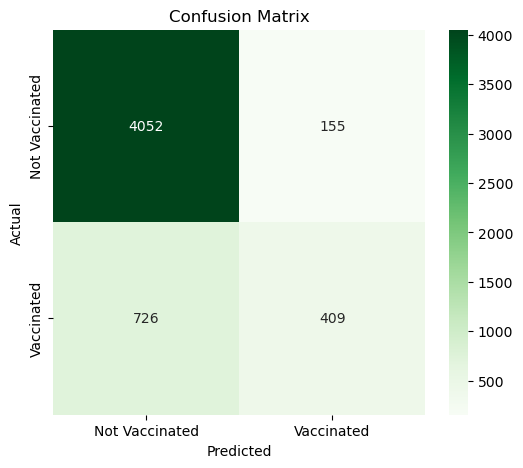

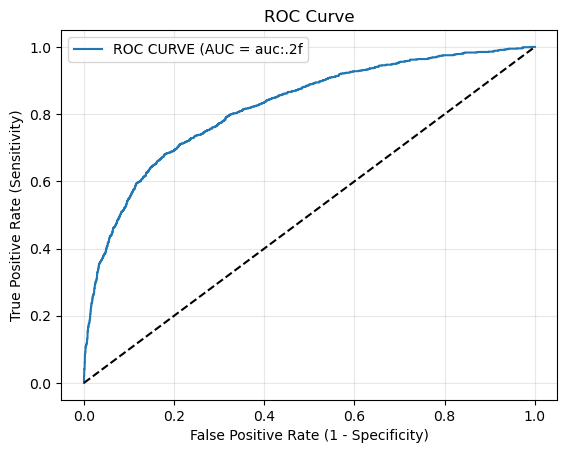

In [25]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

evaluate_model(best_rf, X_test, y_test)

Random Forest improves predictive performance by combining multiple decision trees and aggregating their predictions, allowing the model to capture more complex relationships in the data.

Hyperparameter tuning identified the following optimal configuration:

- Number of trees (n_estimators): 200
- Maximum tree depth (max_depth): 20
- Minimum samples per split (min_samples_split): 5
- Class weighting: balanced

This tuned ensemble model achieved the following performance:

- Accuracy: 0.828
- ROC-AUC: 0.825

These results indicate that the model performs well in distinguishing between vaccinated and non-vaccinated individuals during the H1N1 influenza vaccination campaig

### Decision Tree
Notebook Explanation

A Decision Tree model was implemented to explore how simple rule-based models perform in predicting vaccination behavior. Decision trees split the data into smaller groups based on features that best separate vaccinated and non-vaccinated individuals. This approach produces an interpretable model that can highlight important factors influencing vaccine uptake.

Accuracy: 0.7467240733807563
ROC-AUC: 0.6437466818989538

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      4207
           1       0.41      0.47      0.44      1135

    accuracy                           0.75      5342
   macro avg       0.63      0.64      0.64      5342
weighted avg       0.76      0.75      0.75      5342



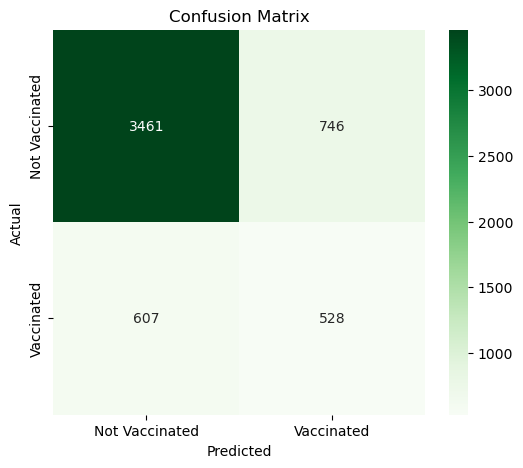

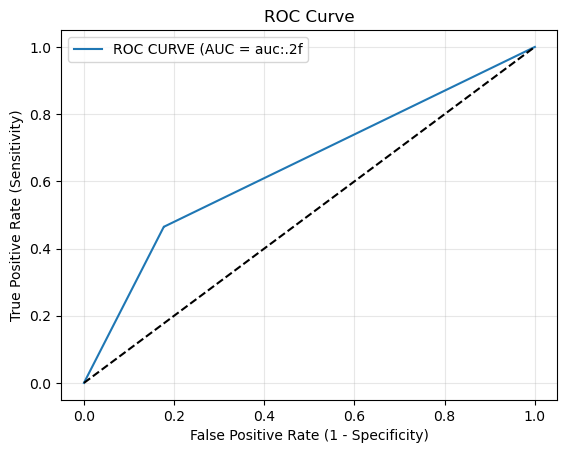

In [26]:
# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Evaluate
evaluate_model(dt_model, X_test, y_test)

#### Ensemble Model – Voting Classifier
To further improve predictive performance, an ensemble approach that combines multiple models is implemented using a Voting Classifier. Ensemble modeling works by combining predictions from several different algorithms in order to produce a more robust final prediction.

In this case, two models are combined:
- Logistic Regression
- Decision Tree
- Random Forest

Each model has different strengths. Logistic regression captures linear relationships in the data, decision trees identify simple decision rules, and Random Forest captures more complex interactions between variables. By combining these models, the ensemble can benefit from the strengths of each individual model.

The voting classifier uses soft voting, meaning it averages the predicted probabilities from each model and selects the final prediction based on the highest probability. This often improves stability and predictive performance compared to using a single model alone.

Accuracy: 0.7895919131411456
ROC-AUC: 0.8008328891746397

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      4207
           1       0.50      0.49      0.50      1135

    accuracy                           0.79      5342
   macro avg       0.68      0.68      0.68      5342
weighted avg       0.79      0.79      0.79      5342



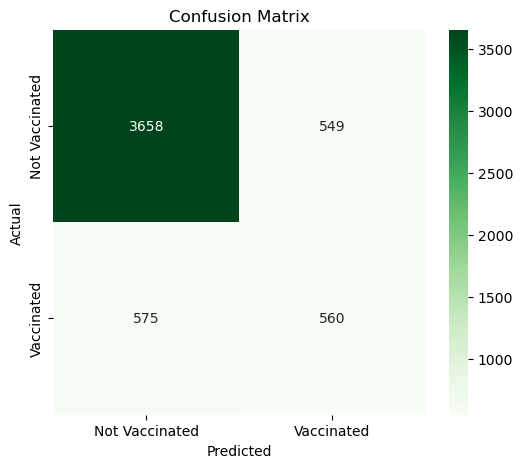

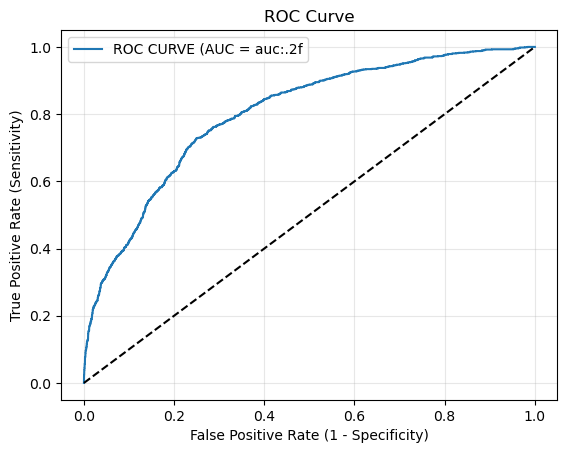

In [27]:
# Define individual models
log_model = best_log_model
rf_model = best_rf
dt_model= dt_model

# Voting ensemble
voting_model = VotingClassifier(
    estimators=[
        ('logistic', log_model),
        ('random_forest', rf_model),
        ('decision_tree', dt_model)
    ],
    voting='soft'
)
voting_model.fit(X_train, y_train)

evaluate_model(voting_model, X_test, y_test,)

##### Full comparison
| Model                        | Accuracy | ROC-AUC   | Recall (Vaccinated) |
| ---------------------------- | -------- | --------- | ------------------- |
| Baseline Logistic Regression | 0.77     | 0.82      | 0.78                |
| Tuned Logistic Regression    | 0.77     | 0.82      | 0.78                |
| Random Forest                | 0.84     | 0.82      | 0.96                |
| DataTree                     | 0.75     | 0.64      | 0.82                |
| Ensemble                     | 0.79     | 0.80      | 0.87                |



#### Final Model Discussion
The Logistic Regression, which served as the baseline model because it is simple and widely used in health research. This model correctly predicts vaccination status for about 77% of individuals, demonstrating that the survey data contains meaningful signals about vaccination behavior. A tuned version of the logistic regression model is also evaluated, but its performance remained nearly identical to the baseline model. A Decision Tree model is also tested to explore a rule-based approach that is easy to interpret, but its predictive performance is lower compared to the other models.

The Random Forest model, achieves the highest overall accuracy at about 84%, indicating the strongest ability to correctly predict vaccination status. A combined ensemble model using a Voting Classifier was also implemented to merge predictions from multiple algorithms. This ensemble model achieved an accuracy of approximately 79%, performing better than the decision tree but slightly below the Random Forest model.

Therefore, the Random Forest model is my final model because it achieved the highest overall predictive performance and strong ability to distinguish between vaccinated and non-vaccinated individuals. These results demonstrate that machine learning techniques can help identify patterns in vaccination behavior and provide insights that may assist public health professionals in designing more effective vaccination campaigns during future disease outbreaks.

## Final Predictions on Unseen Data
Our final step is to apply the model(Random Forest) to new unseen data. The test_set_features dataset contains input features for individuals whose vaccination status is unknown. This allows us to simulate real-world use of the model by generating predictions for new observations.

In [28]:
df_test =pd.read_csv('data/test_set_features.csv')
df_test.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
1,26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
2,26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
3,26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
4,26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird


In [29]:
# Transforming the test features using the already fitted preprocessor we used on trained data
test_features_processed = preprocessor.transform(df_test)
# Convert to DataFrame using the same column names
X_submission = pd.DataFrame(
    test_features_processed, 
    columns=all_column_names, 
    index=df_test.index)


Generate Predictions
- Using the final Random Forest model, we predict whether each individual received the H1N1 vaccine an the brobality of not.

In [30]:
# Predict class labels
test_predictions = rf_model.predict(X_submission)

# Predict probabilities
test_probabilities = rf_model.predict_proba(X_submission)[:, 1]

submission = pd.DataFrame(
    data=test_predictions, 
    index=df_test.index, 
    columns=['h1n1_vaccine']
)
print(submission.head())
print(submission['h1n1_vaccine'].value_counts())

   h1n1_vaccine
0             0
1             0
2             0
3             0
4             0
h1n1_vaccine
0    24116
1     2592
Name: count, dtype: int64


The distrubution of the prediction on uptake of vaccine.

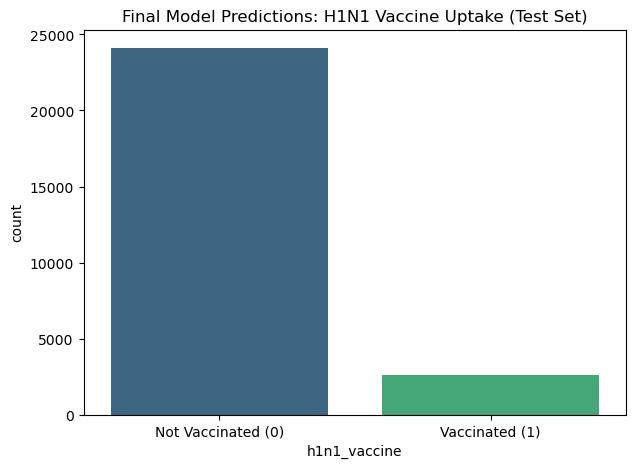

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure(figsize=(7, 5))
sns.countplot(x='h1n1_vaccine', data=submission, palette='viridis')
plt.title('Final Model Predictions: H1N1 Vaccine Uptake (Test Set)')
plt.xticks([0, 1], ['Not Vaccinated (0)', 'Vaccinated (1)'])
plt.show()
plt.savefig('images/final_predictions_distribution.png')

Using the model to see who it predicted as most likely to get the vaccine

In [32]:
# Join predictions back to the original test features to see the characteristics
df_test['predicted_prob'] = test_probabilities

# Look at the top 10 people most likely to get vaccinated
top_targets = df_test.sort_values(by='predicted_prob', ascending=False).head(10)
print(top_targets[['age_group', 'education', 'doctor_recc_h1n1', 'predicted_prob']])

           age_group         education  doctor_recc_h1n1  predicted_prob
18307  35 - 44 Years  College Graduate               1.0        0.870644
961    55 - 64 Years  College Graduate               1.0        0.870525
2412   55 - 64 Years  College Graduate               1.0        0.867860
14125  35 - 44 Years  College Graduate               1.0        0.863421
14097  55 - 64 Years      Some College               1.0        0.858279
18449  55 - 64 Years  College Graduate               1.0        0.858016
24900  18 - 34 Years  College Graduate               1.0        0.857088
19972  55 - 64 Years      Some College               1.0        0.856665
23113  55 - 64 Years      Some College               1.0        0.856633
23233  35 - 44 Years  College Graduate               1.0        0.852098


## Key Findings

The machine learning models developed in this project were able to predict H1N1 vaccination status with reasonable accuracy. The best-performing model, the Random Forest classifier, achieved an accuracy of approximately 84% and a strong ROC-AUC score, indicating a good ability to distinguish between individuals who received the vaccine and those who did not.

However, the model performed better at identifying individuals who did not receive the vaccine compared to those who did. This is reflected in the lower recall for vaccinated individuals, suggesting that some vaccinated individuals were misclassified. This imbalance highlights the challenge of predicting less frequent outcomes in real-world datasets.

Feature importance analysis from the Random Forest model showed that the most influential factors in predicting vaccination behavior included:
- Doctor recommendation for the H1N1 vaccine
- Perceived risk of H1N1 infection
- Belief in vaccine effectiveness
- Health worker status

These findings suggest that both behavioral perceptions and healthcare influence play a critical role in vaccination decisions.

## Recommendations

Based on the findings from this analysis and the predictive modeling results, several recommendations can be made for decision-making:

1. Target Vaccine Education Campaigns
The analysis suggests that individuals’ attitudes toward vaccines and perceived risks strongly influence vaccination decisions. Public health campaigns should therefore focus on improving awareness about vaccine safety and effectiveness.

2. Strengthen Healthcare Provider Recommendations
Medical professionals play a key role in influencing vaccination decisions. Encouraging healthcare providers to actively recommend vaccines may increase vaccination uptake.

3. Focus on High-Risk and Low-Uptake Groups
Predictive models can help identify population groups that are less likely to get vaccinated. Targeted interventions can then be designed to address the specific concerns or barriers faced by these groups.

4. Use Data-Driven Approaches in Public Health Planning
Machine learning models like the one developed in this project can help public health agencies anticipate vaccination patterns and allocate resources more effectively.

### Appendix

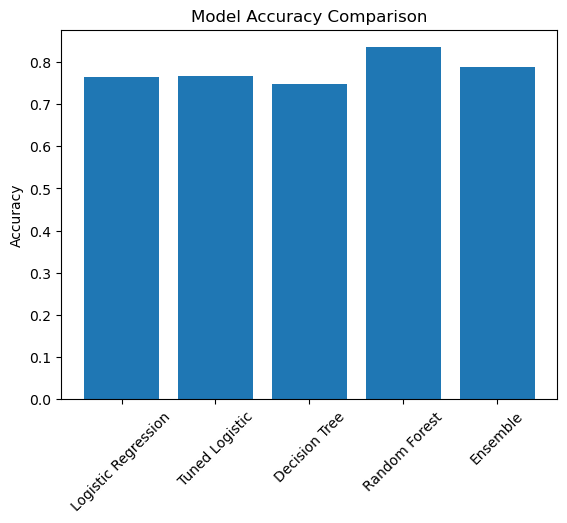

In [33]:
# model performance comparison chart
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Tuned Logistic", "Decision Tree", "Random Forest", "Ensemble"]
accuracy = [0.765, 0.766, 0.747, 0.835, 0.789]

plt.figure()

plt.bar(models, accuracy)

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.savefig("images/model_comparison.png")

plt.show()

[Click here to view the full Presentation PDF](H1N1ML.pdf)